In [10]:
import os
import pandas as pd
import numpy as np
import warnings

from sklearn.metrics import mean_squared_error , root_mean_squared_error,accuracy_score
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imbpipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.combine import SMOTETomek
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report,balanced_accuracy_score,precision_recall_curve,auc
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
import joblib


MODEL_FILE="model5.pkl"
PIPELINE_FILE="pipeline5.pkl"
def built_pipeline(num_data,flag_data,cat_data):
    num_pipeline=Pipeline([("imputer",SimpleImputer(strategy="median")),
                       ("standard",StandardScaler())
                      ])

    cat_pipeline=Pipeline([("coder",OneHotEncoder(handle_unknown='ignore'))])
    flag_pipeline=Pipeline([("flag",SimpleImputer(strategy="median"))])
    
    merge_pipeline=ColumnTransformer([
        ("num",num_pipeline,num_data),
        ("cat",cat_pipeline,cat_data) ,
        ("flag",flag_pipeline,flag_data)
    ])
    return merge_pipeline


if not os.path.exists(MODEL_FILE):
    warnings.filterwarnings("ignore",category=UserWarning)

    data=pd.read_csv("retail_fraud_detection_100k.csv")
    mapping={"Low":0,"Medium":1,"High":2}
    data['fraud_risk_labels'] = data["fraud_risk"].map(mapping)
    data['fraud_risk_labels'].value_counts()
    # data.isnull().sum()
    # data.duplicated().sum()
    data["fraud_risk_labels"].value_counts(normalize=True)*100

    mean_amount = data.groupby('payment_method')['transaction_amount'].transform('mean')
    
   
    
    # Naya feature: Kitna guna bada hai transaction normal se
    
    data['amt_deviation_by_payment'] = data['transaction_amount'] / mean_amount
    data['payment_location_combo'] = data['payment_method'].astype(str) + '_' + data['is_international'].astype(str)
    
    
    
    
    
    # 2. Deviation by Merchant Amount
    mean_amt_merchant = data.groupby('merchant_category')['transaction_amount'].transform('mean')
    data['amt_deviation_by_merchant'] = data['transaction_amount'] / mean_amt_merchant
    
    # 3. Merchant + Payment Combo
    data['merchant_payment_combo'] = data['merchant_category'].astype(str) + '_' + data['payment_method'].astype(str)
    
    
    
    
    
    data['avg_transaction_amount_7d'].describe()
    data['ratio_amount']=data['transaction_amount']/ (data['avg_transaction_amount_7d'])
    data.drop("fraud_risk",axis=1,inplace=True)
    data['transaction_timestamp']=pd.to_datetime(data['transaction_timestamp'])
    
    
    data['Trans_Aday']=data['transaction_timestamp'].dt.date
    # data['Trans_weaksofdays']=data['transaction_timestamp'].dt.dayofweek
    # Data ko sort karein
    data = data.sort_values(['customer_id', 'transaction_timestamp']) 
    data.drop('transaction_timestamp',axis=1,inplace=True)
    data["Per_day_Avgtransaction"] =data.groupby("Trans_Aday")["transaction_amount"].transform('mean')
    data["Per_day_random_transaction"] =data.groupby("Trans_Aday")["transaction_amount"].transform('median')
    
    data["transaction_frequency_24h"]=data["transaction_frequency_24h"].replace(0,1)
    data["failed_transaction_count_24h"]=data["failed_transaction_count_24h"].replace(0,1)
    # else:
    # Addition of divicce and country
    data['device_location_combo']= data['device_type'].astype(str) + "_" + data['location'].astype(str)
     
    data["avg_faild_transaction"]=data["transaction_frequency_24h"]/data["failed_transaction_count_24h"]
    data.drop("account_age_days",axis=1)
    from sklearn.model_selection import StratifiedShuffleSplit
    split=StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
    for train ,test in split.split(data,data['fraud_risk_labels']):
        strat_train=data.loc[train]
        strat_test=data.loc[test]
    datatr=strat_train.copy()
    datatest=strat_test.copy()
    strat_test.to_csv("data_test.csv",index=False)
    labels=datatr['fraud_risk_labels']
    # ,'unusual_location_flag',"is_international","velocity_flag","unusual_amount_flag"
    drop_col=["fraud_risk_labels","transaction_id","account_age_days","avg_transaction_amount_7d","previous_fraud_flag","customer_id","fraud_flag","multiple_transactions_short_time"]
    features=datatr.drop(drop_col,axis=1)
    labels_test=datatest['fraud_risk_labels']
    drop_cols=["fraud_risk_labels","transaction_id","account_age_days","avg_transaction_amount_7d","previous_fraud_flag","customer_id","fraud_flag","multiple_transactions_short_time"]
    features_test=datatest.drop(drop_cols,axis=1)
    import numpy as np
    flag_data=['high_risk_device_flag' ,'unusual_location_flag',"is_international",'unusual_amount_flag']	
    numall_data=features.select_dtypes(include=[np.number]).columns.tolist()
    num_data=[col for col in numall_data if col not in flag_data]
    cat_data=features.select_dtypes(exclude=[np.number]).columns.tolist()
    class custom_xgboost(XGBClassifier):
        def __init__(self,threshold,**kwargs):
            self.threshold=kwargs.pop("threshold",threshold)
            super().__init__(**kwargs)
        def get_params (self,deep=True):
            params=super().get_params(deep=deep)
            params['threshold']=self.threshold
            return params
        def predict(self,x):
            probility=self.predict_proba(x)
            prob=np.argmax(probility,axis=1)
            prob[probility[:,2]>=self.threshold] =2
            # prob[probility[:,1]>=0.42]=1
            return prob

   
    
    model1=custom_xgboost(n_estimators=500,threshold=0.40,max_depth=7,min_child_weight=30,subsample=0.7,reg_alpha=0.2
                           , colsample_bytree=0.7,reg_lambda=4.0,learning_rate=0.02,random_state=42)
    
    smote_control=SMOTETomek(sampling_strategy="not majority",random_state=42,n_jobs=-1)
    main_pipline=imbpipeline([(
    'smote',smote_control),('xgb',model1) ])
    
  
    pipeline=built_pipeline(num_data,flag_data,cat_data)
    fraud_prepared= pipeline.fit_transform(features)

    # here this is for test data we can identify -->
    
    fraudtest_prepared= pipeline.transform(features_test)
    
    transform_xgboost=main_pipline.fit(fraud_prepared,labels)
    pred_xgboost=transform_xgboost.predict(fraudtest_prepared)
    predt_xgboost=transform_xgboost.predict(fraud_prepared)
    # now we are define the accuracy of our model
    
    # here i am using ensemble learning

    
    joblib.dump(transform_xgboost,MODEL_FILE,compress=('lzma',9))
    # joblib.dump({"xgb":model1,"lgm":model2}  ,MODEL_FILE,compress=('lzma',9))

    joblib.dump(pipeline,PIPELINE_FILE)
    print("model train and saved")
else:
    
    model=joblib.load(MODEL_FILE)
    pipeline=joblib.load(PIPELINE_FILE)
    transform_data=pipeline.transform(strat_test)
    prediction_df=model.predict(transform_data)
    prediction=pd.DataFrame(prediction,columns=["prediction_fraud_risk"])
    
    prediction.to_csv("output_fraud_detection.csv",index=False)
    print("Work is done ")
    
    
    


Work is done 


In [2]:
scoring_xgboost=cross_val_score(model1,fraud_prepared,labels,scoring="f1_macro",cv=5,n_jobs=-1)
print(f"The xgboost accuracy is :{scoring_xgboost}")
print(pd.Series(scoring_xgboost).describe())

The xgboost accuracy is :[0.70517435 0.70499826 0.70159497 0.70910867 0.70285026]
count    5.000000
mean     0.704745
std      0.002864
min      0.701595
25%      0.702850
50%      0.704998
75%      0.705174
max      0.709109
dtype: float64


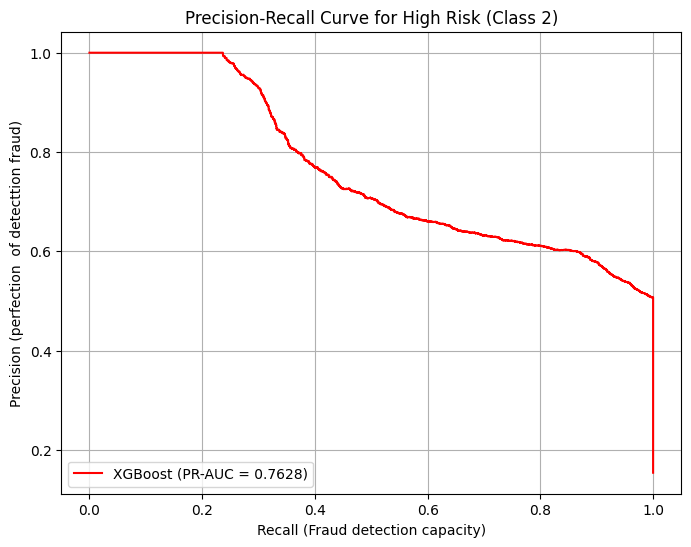

XGBoost High-Risk PR-AUC: 0.7628


In [11]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# 1. Dono models ki probabilities nikaliye
# predict_proba se hume har class ki probability milti hai, hume sirf 'High (2)' yani index 2 chahiye
prob_xgb = model1.predict_proba(fraudtest_prepared)[:, 2]
# prob_lgb = model2.predict_proba(fraudtest_prepared)[:, 2]

# final_predict=((prob_xgb*0.4)+(prob_lgb*0.6))
# 2. Actual labels ko binary banayein (Kya sach mein High Risk '2' hai ya nahi?)
# Kyuki PR curve binary input maangta hai
y_test_binary = (labels_test == 2).astype(int)

# 3. Precision, Recall aur AUC calculate karein
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test_binary,prob_xgb)
auc_xgb = auc(recall_xgb, precision_xgb)

# precision_f, recall_f, _ = precision_recall_curve(y_test_binary, final_predict)
# auc_f = auc(recall_f, precision_f)

# precision_lgb, recall_lgb, _ = precision_recall_curve(y_test_binary, prob_lgb)
# auc_lgb = auc(recall_lgb, precision_lgb)

# 4. Plot karne ka tareeka
plt.figure(figsize=(8, 6))
plt.plot(recall_xgb, precision_xgb, color='red', label=f'XGBoost (PR-AUC = {auc_xgb:.4f})')
plt.title('Precision-Recall Curve for High Risk (Class 2)')
plt.xlabel('Recall (Fraud detection capacity)')
plt.ylabel('Precision (perfection  of detecttion fraud)')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

print(f"XGBoost High-Risk PR-AUC: {auc_xgb:.4f}")


In [12]:

from sklearn.metrics import classification_report,balanced_accuracy_score,precision_recall_curve,auc

print(classification_report(labels_test,model1.predict(fraudtest_prepared)))
# from sklearn.metrics import classification_report,balanced_accuracy_score
print(pd.Series(scoring_xgboost).describe())
print(model1.feature_importances_)


              precision    recall  f1-score   support

           0       0.66      0.88      0.75      6493
           1       0.83      0.54      0.66     10428
           2       0.60      0.87      0.71      3079

    accuracy                           0.70     20000
   macro avg       0.70      0.76      0.71     20000
weighted avg       0.74      0.70      0.70     20000

count    5.000000
mean     0.704745
std      0.002864
min      0.701595
25%      0.702850
50%      0.704998
75%      0.705174
max      0.709109
dtype: float64
[0.00204838 0.02575008 0.02132478 0.03515191 0.0034544  0.00233714
 0.0175148  0.00080956 0.00078716 0.00944878 0.00335395 0.00364954
 0.00343655 0.00298819 0.00269144 0.00965475 0.00683679 0.01072013
 0.01198368 0.0131011  0.01307114 0.01396695 0.01051049 0.01109248
 0.01315435 0.01178141 0.01451373 0.01127197 0.01198894 0.01029679
 0.00865204 0.00632026 0.00735363 0.01114954 0.00853306 0.01030594
 0.00945139 0.00968919 0.00764758 0.0088197  0.00083303 0.

In [13]:
# num_data=num_data.astype(int)
number=data.select_dtypes(include=[np.number])
correlation = number.corr()['fraud_risk_labels'].sort_values()
print(correlation)

avg_transaction_amount_7d          -0.159565
account_age_days                   -0.000941
Per_day_Avgtransaction              0.012262
Per_day_random_transaction          0.013643
avg_faild_transaction               0.059722
high_risk_device_flag               0.138583
amt_deviation_by_payment            0.239595
amt_deviation_by_merchant           0.239640
transaction_amount                  0.239670
ratio_amount                        0.271295
failed_transaction_count_24h        0.293754
transaction_frequency_24h           0.355163
velocity_flag                       0.364523
multiple_transactions_short_time    0.375814
unusual_amount_flag                 0.379432
previous_fraud_flag                 0.449788
unusual_location_flag               0.450132
is_international                    0.450132
fraud_flag                          0.700705
fraud_risk_labels                   1.000000
Name: fraud_risk_labels, dtype: float64


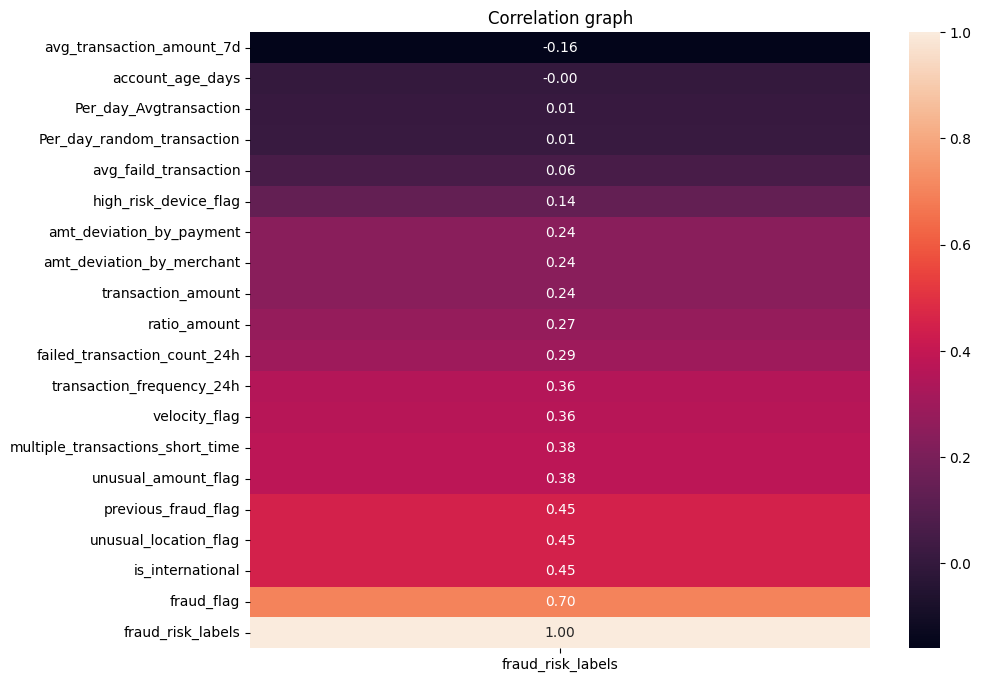

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
sns.heatmap(correlation.to_frame(),fmt='.2f',annot=True,color="blue")
plt.title("Correlation graph")
plt.show()

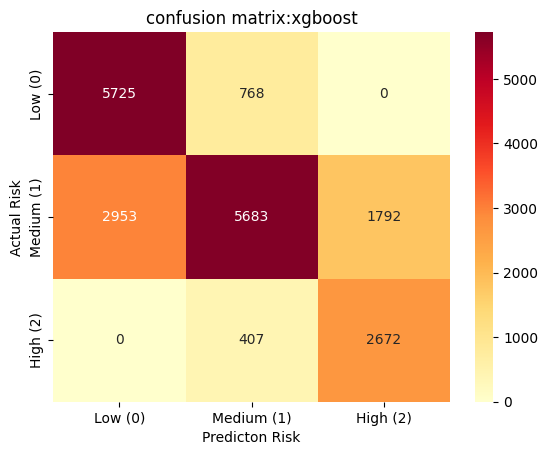

In [15]:

cm=confusion_matrix(labels_test,model1.predict(fraudtest_prepared))
# cm=confusion_matrix(labels_test,correct_preds)

# pivot_table=pd.pivot(da
sns.heatmap(cm,annot=True,fmt='d',cmap="YlOrRd",xticklabels=['Low (0)', 'Medium (1)', 'High (2)'],
            yticklabels=['Low (0)', 'Medium (1)', 'High (2)'])
plt.title("confusion matrix:xgboost")
plt.xlabel("Predicton Risk")
plt.ylabel("Actual Risk")
    
plt.show()

In [16]:



param_dist = {
    'n_estimators': [100, 200, 300,500,600,700],
    'max_depth': [5,7,8,10,12,15],
    'min_child_weight': [10,15,20,25,30],
    # 'num_leaves': [5,10,15,20,25,30,35,40,50,60,70,80],
    'learning_rate':[0.01,0.02,0.03,0.04,0.05]
}

random_search = RandomizedSearchCV(model1, param_distributions=param_dist, n_iter=5, cv=3, scoring='average_precision',n_jobs=-1)
random_search.fit(fraud_prepared,labels)



,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","custom_xgboos...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.02, ...], 'max_depth': [5, 7, ...], 'min_child_weight': [10, 15, ...], 'n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be 